In [2]:
# 1. Download the zip file from UCI
!wget "https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip"

# 2. Unzip it (this will extract 'Concrete_Data.xls')
!unzip concrete+compressive+strength.zip

import pandas as pd

# 3. Load the Excel file

df = pd.read_excel('Concrete_Data.xls')

# 4. Take a look at the data structure
print("Dataset Shape:", df.shape)
df.head()

--2026-03-08 06:19:06--  https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘concrete+compressive+strength.zip’

concrete+compressiv     [ <=>                ]  33.64K  --.-KB/s    in 0.05s   

2026-03-08 06:19:07 (693 KB/s) - ‘concrete+compressive+strength.zip’ saved [34444]

Archive:  concrete+compressive+strength.zip
  inflating: Concrete_Data.xls       
  inflating: Concrete_Readme.txt     
Dataset Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
# Shortening names for easier coding later
df.columns = [
    'Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water',
    'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Strength'
]

# Check the first few rows with new names
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate entries: {duplicates}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

Number of duplicate entries: 25

Missing values per column:
Cement                0
Blast_Furnace_Slag    0
Fly_Ash               0
Water                 0
Superplasticizer      0
Coarse_Aggregate      0
Fine_Aggregate        0
Age                   0
Strength              0
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

# 1. Remove Duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset size after removing duplicates: {df.shape}")

# 2. Define Features (X) and Target (y)
X = df.drop('Strength', axis=1)
y = df['Strength']

# 3. Split 70% Train, 30% Temp (to be split into Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 4. Split the 30% Temp into 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Final Counts -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Dataset size after removing duplicates: (1005, 9)
Final Counts -> Train: 703, Val: 151, Test: 151


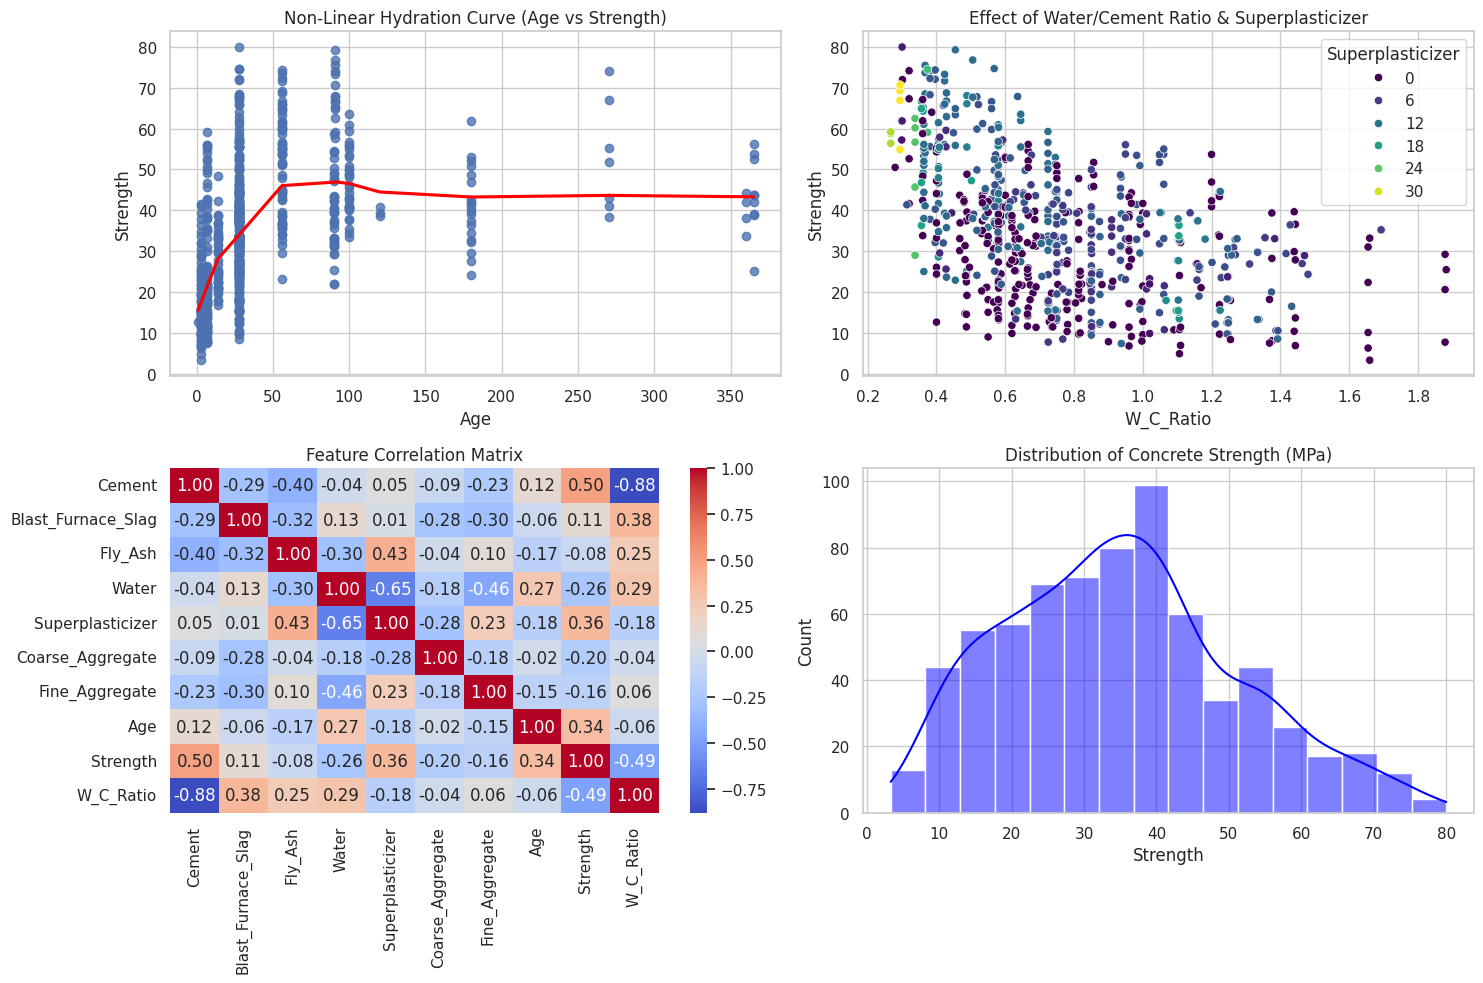

In [13]:
def perform_eda(X_train, y_train):
    train_data = X_train.copy()
    train_data['Strength'] = y_train

    # Analysis 1: The Hydration Curve (Age vs Strength)
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 2, 1)
    # Using lowess=True helps visualize the non-linear "elbow" in concrete curing
    sns.regplot(data=train_data, x='Age', y='Strength', lowess=True, line_kws={'color':'red'})
    plt.title("Non-Linear Hydration Curve (Age vs Strength)")

    # Analysis 2: Water-Cement Ratio Proxy
    # This is a key Engineering Insight
    plt.subplot(2, 2, 2)
    train_data['W_C_Ratio'] = train_data['Water'] / train_data['Cement']
    sns.scatterplot(data=train_data, x='W_C_Ratio', y='Strength', hue='Superplasticizer', palette='viridis')
    plt.title("Effect of Water/Cement Ratio & Superplasticizer")

    # Analysis 3: Interaction Heatmap
    plt.subplot(2, 2, 3)
    sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Feature Correlation Matrix")

    # Analysis 4: Distribution of Strength
    plt.subplot(2, 2, 4)
    sns.histplot(y_train, kde=True, color='blue')
    plt.title("Distribution of Concrete Strength (MPa)")

    plt.tight_layout()
    plt.show()

perform_eda(X_train, y_train)

In [7]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class AdaBoostR2FromScratch:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.alphas = [] # To store the weight of each estimator
        self.estimators = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples = X.shape[0]
        # 1. Initialize weights
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            # 2. Fit a weak learner (Decision Tree Stump)
            # We pass the weights to the 'sample_weight' parameter
            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X, y, sample_weight=weights)

            # 3. Calculate errors
            y_predict = stump.predict(X)
            errors = np.abs(y_predict - y)
            max_error = np.max(errors)

            if max_error == 0: break # Perfect fit

            # Relative errors (normalized)
            rel_errors = errors / max_error

            # Weighted average error (L)
            weighted_error_L = np.sum(weights * rel_errors)

            if weighted_error_L >= 0.5: break # Stop if model is worse than random

            # 4. Calculate beta and alpha (model confidence)
            beta = weighted_error_L / (1 - weighted_error_L)
            # Alpha is used for the final prediction weight
            alpha = np.log(1 / beta)

            # 5. Update weights for the next learner
            # Samples with high relative error keep higher weights
            weights = weights * (beta ** (1 - rel_errors))
            weights /= np.sum(weights) # Normalize weights

            self.estimators.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        # Final prediction is the weighted median of all learners
        X = np.array(X)
        predictions = np.array([stump.predict(X) for stump in self.estimators]).T
        alphas = np.array(self.alphas)

        # Sort predictions and find the weighted median
        final_preds = []
        for i in range(len(X)):
            # Sort by predicted value
            sorted_indices = np.argsort(predictions[i])
            sorted_predictions = predictions[i][sorted_indices]
            sorted_alphas = alphas[sorted_indices]

            # Find index where cumulative weight exceeds half of total weight
            cum_alpha = np.cumsum(sorted_alphas)
            threshold = 0.5 * np.sum(sorted_alphas)
            median_idx = np.where(cum_alpha >= threshold)[0][0]
            final_preds.append(sorted_predictions[median_idx])

        return np.array(final_preds)

Starting validation loop...
M =     5 | Validation R2: 0.4442
M =    10 | Validation R2: 0.4190
M =    20 | Validation R2: 0.5141
M =    40 | Validation R2: 0.5106
M =    60 | Validation R2: 0.5231
M =    80 | Validation R2: 0.5112
M =   100 | Validation R2: 0.5127
M =   150 | Validation R2: 0.5098
M =   200 | Validation R2: 0.5088
M =   500 | Validation R2: 0.5088
M =  1000 | Validation R2: 0.5088
M =  5000 | Validation R2: 0.5088
M = 10000 | Validation R2: 0.5088

Best M selected: 60 with R2 = 0.5231


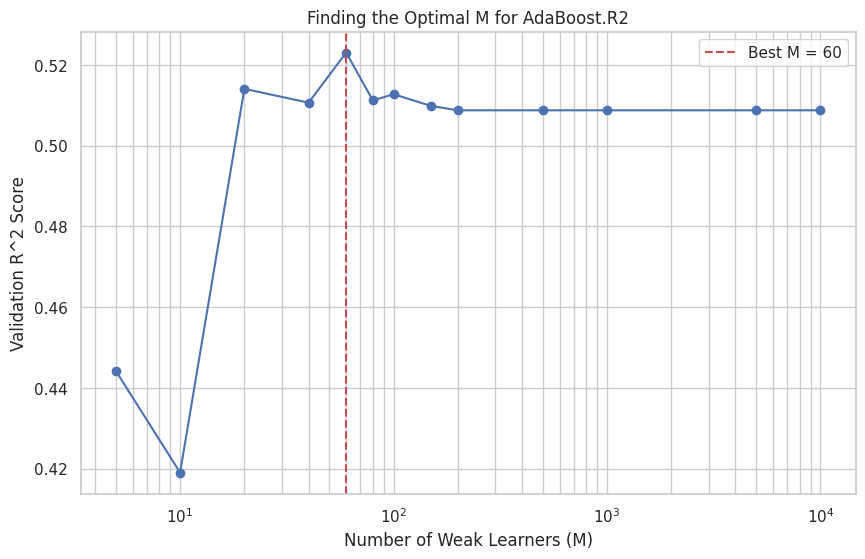

In [8]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# List of M values to test
M_values = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000]
val_r2_scores = []

print("Starting validation loop...")

for m in M_values:
    # Initialize and train our 'from scratch' model
    model = AdaBoostR2FromScratch(n_estimators=m)
    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Calculate R2 score
    score = r2_score(y_val, y_val_pred)
    val_r2_scores.append(score)
    print(f"M = {m:5} | Validation R2: {score:.4f}")

# Find the best M
best_idx = np.argmax(val_r2_scores)
best_M = M_values[best_idx]
print(f"\nBest M selected: {best_M} with R2 = {val_r2_scores[best_idx]:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(M_values, val_r2_scores, marker='o', linestyle='-', color='b')
plt.xscale('log') # Log scale helps visualize values from 5 to 10,000
plt.xlabel('Number of Weak Learners (M)')
plt.ylabel('Validation R^2 Score')
plt.title('Finding the Optimal M for AdaBoost.R2')
plt.grid(True, which="both", ls="-")
plt.axvline(best_M, color='r', linestyle='--', label=f'Best M = {best_M}')
plt.legend()
plt.show()

Final Test R2 (From Scratch): 0.4417


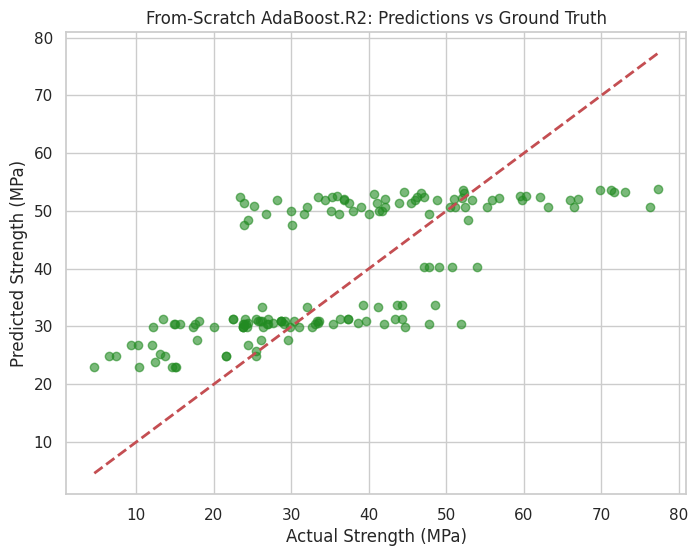

In [9]:
# 1. Train the final 'from scratch' model using the best M
best_model_scratch = AdaBoostR2FromScratch(n_estimators=60)
best_model_scratch.fit(X_train, y_train)

# 2. Predict on the Test Set
y_test_pred_scratch = best_model_scratch.predict(X_test)

# 3. Calculate Final R2 Score
test_r2_scratch = r2_score(y_test, y_test_pred_scratch)
print(f"Final Test R2 (From Scratch): {test_r2_scratch:.4f}")

# 4. Scatter Plot: Predictions vs Ground Truths
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_scratch, alpha=0.6, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('From-Scratch AdaBoost.R2: Predictions vs Ground Truth')
plt.show()


Final Test R2 (Scikit-learn): 0.4428


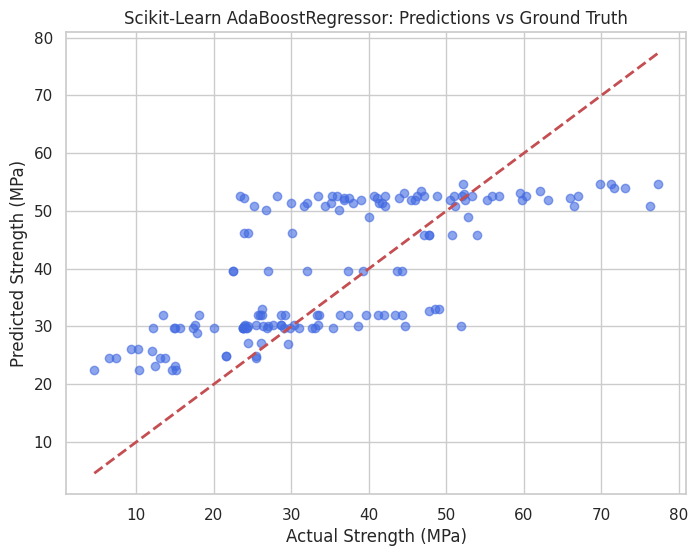

In [10]:
from sklearn.ensemble import AdaBoostRegressor

# 1. Initialize sklearn's version with the same parameters
# loss='linear' corresponds to the basic AdaBoost.R2 algorithm
sklearn_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=60,
    loss='linear',
    random_state=42
)

# 2. Fit and Predict
sklearn_model.fit(X_train, y_train)
y_test_pred_sklearn = sklearn_model.predict(X_test)

# 3. Calculate R2
test_r2_sklearn = r2_score(y_test, y_test_pred_sklearn)
print(f"Final Test R2 (Scikit-learn): {test_r2_sklearn:.4f}")

# 4. Visualization for comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_sklearn, alpha=0.6, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Scikit-Learn AdaBoostRegressor: Predictions vs Ground Truth')
plt.show()